In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, welch

import h5py


import sys, os, glob
sys.path.append('../../')
import analysis_utils as utils
import calc_gas_collision_spectrum as calc_gas

from scipy.optimize import curve_fit as curve_fit

utils.load_plotting_setting()

In [2]:
import inspect
print(utils.__file__)
print(inspect.getsource(utils.recon_pulse))
print(utils.recon_pulse.__code__.co_filename)

/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../analysis_utils.py
def recon_pulse(idx, dtt, zz_bp, dd,
                c_imp=None,
                gamma_damping=None,
                analysis_window_length=100000,
                prepulse_window_length=5000,
                search_window_length=100,###i believe these are in nanoseconds
                pulse_length=20,
                lowpass_freq=60000,
                lowpass_order=3):

    if idx < prepulse_window_length:
        print('Skipping pulse too close to the beginning of the file')
        return None, None, None, np.nan, np.nan, np.nan

    fs = int(np.ceil(1 / dtt))

    window, pulse_idx_in_window = get_analysis_window(dd, idx, analysis_window_length)
    prepulse_window = get_prepulse_window(dd, idx, prepulse_window_length)

    # FFT the bandpassed z signal in the prepulse window to find
    # the resonant frequency
    zzk = rfft(zz_bp[prepulse

In [3]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../calc_gas_collision_spectrum.py'>

## Summary

This notebook shows the reconstruction of calibration pulses using fixed `c_imp` and fixed `gamma_damping` in reconstruction.

## Read the processed calibration data

In [4]:
sphere = 'sphere_20260215'

def read_recon(dataset, voltages):
    file = rf'/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/data_processed/pulse_calibration/{sphere}/{dataset}_processed.hdf5'
    #print(file)
    amps_all, pulse_shapes_all, indices_in_win, zz_pulses_all, drive_area_all, f_res_all, noise_level_all = [], [], [], [], [], [], []
    f = h5py.File(file, 'r')
    for v in voltages:
        amps = f['data_processed'][f'amplitudes_{v}v'][:]
        ps = f['data_processed'][f'pulse_shapes_{v}v'][:]
        indices = f['data_processed'][f'pulse_indices_in_win_{v}v'][:]
        zz = f['data_processed'][f'z_signal_{v}v'][:]
        drive_area = f['data_processed'][f'drive_area_{v}v'][:]
        f_res = f['data_processed'][f'f_res_{v}v'][:]
        noise_level = f['data_processed'][f'noise_level_{v}v'][:]
        #print(amps)

        amps_all.append(amps)
        pulse_shapes_all.append(ps)
        indices_in_win.append(indices)
        zz_pulses_all.append(zz)
        drive_area_all.append(drive_area)
        f_res_all.append(f_res)
        noise_level_all.append(noise_level)

    try:
        amps_noise = f['data_processed'][f'amplitudes_noise_2.5v'][:]
        amps_noise_search = f['data_processed'][f'amplitudes_noise_search_2.5v'][:]
    except:
        amps_noise = None
        amps_noise_search = None

    try:
        noise_waveforms = f['data_processed'][f'noise_waveforms_2.5v'][:]
    except:
        noise_waveforms = None

    try:
        noise_waveforms_search = f['data_processed'][f'noise_waveforms_search_2.5v'][:]
    except:
        noise_waveforms_search = None

    try:
        noise_drive_area = f['data_processed'][f'noise_drive_area_2.5v'][:]
        noise_f_res      = f['data_processed'][f'noise_f_res_2.5v'][:]
        noise_noise_level = f['data_processed'][f'noise_noise_level_2.5v'][:]
    except:
        noise_drive_area = None
        noise_f_res = None
        noise_noise_level = None

    f.close()

    return (amps_all, amps_noise, amps_noise_search, pulse_shapes_all, indices_in_win,
            zz_pulses_all, drive_area_all, f_res_all, noise_level_all,
            noise_waveforms, noise_waveforms_search,
            noise_drive_area, noise_f_res, noise_noise_level)

In [5]:
dataset_0 = '20260219_p6e_4e-8mbar_d137khz_0'
dataset_1 = '20260219_p6e_4e-8mbar_d137khz_1_afterxe'
dataset_2 = '20260219_p6e_4e-8mbar_d137khz_2_afterkr'
dataset_3 = '20260219_p6e_4e-8mbar_d137khz_3_aftersf6'
datasets_all = [dataset_0, dataset_1, dataset_2, dataset_3]

voltages = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]

(amps_all_0, amps_noise_0, amps_noise_search_0, pulse_shapes_all_0, indices_0, zz_pulses_all_0,
 drive_area_all_0, f_res_all_0, noise_level_all_0,
 noise_waveforms_0, noise_waveforms_search_0,
 noise_drive_area_0, noise_f_res_0, noise_noise_level_0) = read_recon(dataset_0, voltages=voltages)

(amps_all_1, amps_noise_1, amps_noise_search_1, pulse_shapes_all_1, indices_1, zz_pulses_all_1,
 drive_area_all_1, f_res_all_1, noise_level_all_1,
 noise_waveforms_1, noise_waveforms_search_1,
 noise_drive_area_1, noise_f_res_1, noise_noise_level_1) = read_recon(dataset_1, voltages=voltages)

(amps_all_2, amps_noise_2, amps_noise_search_2, pulse_shapes_all_2, indices_2, zz_pulses_all_2,
 drive_area_all_2, f_res_all_2, noise_level_all_2,
 noise_waveforms_2, noise_waveforms_search_2,
 noise_drive_area_2, noise_f_res_2, noise_noise_level_2) = read_recon(dataset_2, voltages=voltages)

(amps_all_3, amps_noise_3, amps_noise_search_3, pulse_shapes_all_3, indices_3, zz_pulses_all_3,
 drive_area_all_3, f_res_all_3, noise_level_all_3,
 noise_waveforms_3, noise_waveforms_search_3,
 noise_drive_area_3, noise_f_res_3, noise_noise_level_3) = read_recon(dataset_3, voltages=voltages)

amp2keV 10333.876527980758
Fitted sigma: [35.84298549 58.56128175 47.3116556  56.34800512 50.99873414 57.97195147
 52.82878686 68.91162652] keV/c
Noise level 55.59240608684542 keV/c
amp2keV 10835.890130913587
Fitted sigma: [39.13080049 55.03388655 55.62520164 59.78407212 71.80216069 86.40953301
 89.48302102 60.71066639] keV/c
Noise level 49.485896192798705 keV/c
amp2keV 10375.12672044546
Fitted sigma: [35.7214644  38.56760281 52.14326646 50.32994345 51.96156595 52.21781926
 49.54200498 49.90352273] keV/c
Noise level 50.5788326690136 keV/c
amp2keV 10649.890803386292
Fitted sigma: [31.32417621 42.05334439 38.98757618 48.31416333 46.17474841 62.58430808
 67.52397429 61.55238132] keV/c
Noise level 45.08909177797776 keV/c


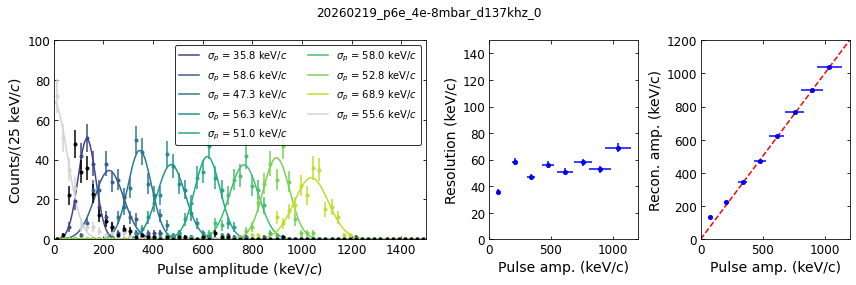

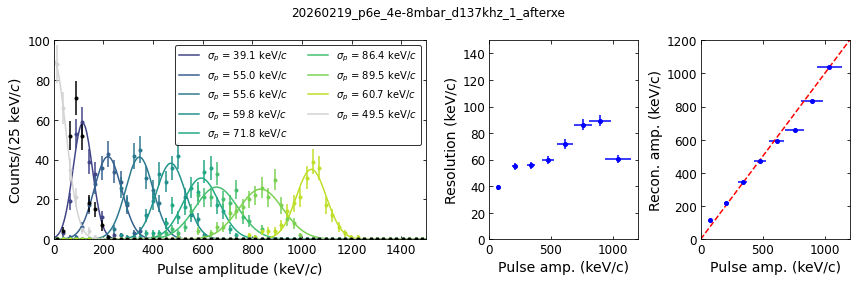

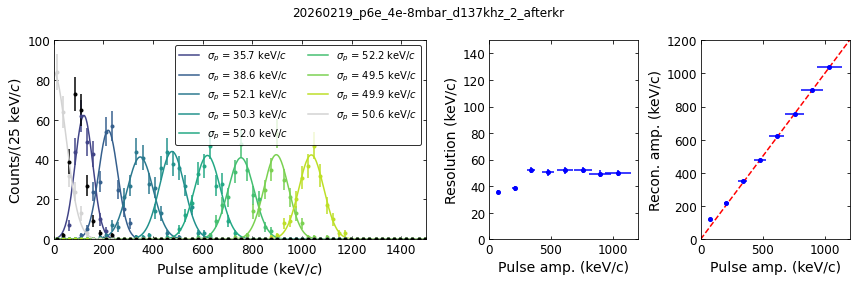

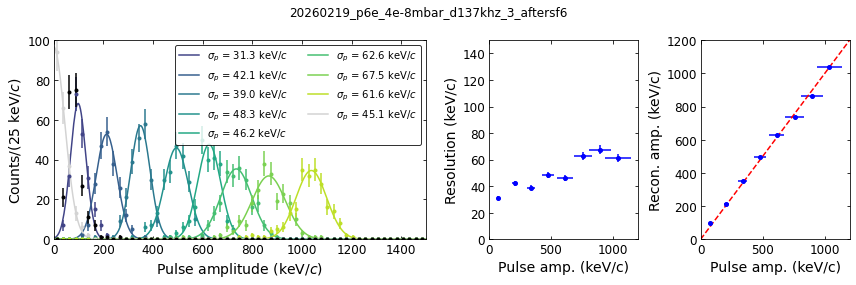

In [6]:
pulse_amp = np.asarray([74, 207, 339, 479, 614, 758, 895, 1038])
pulse_amp_err = pulse_amp * 0.10

amps_all = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
amps_noise_all = [amps_noise_0, amps_noise_1, amps_noise_2, amps_noise_3]
amps_noise_search_all = [amps_noise_search_0, amps_noise_search_1, amps_noise_search_2, amps_noise_search_3]

#print("amps all", amps_all)

amp2kev_bin = 10500
for j in range(len(amps_all)):
    bins = np.arange(0, 3000, 25) / amp2kev_bin
    hhs, bcs, gps = utils.fit_amps_gaus(amps_all[j], bins=bins, noise=False, return_bins=False)

    amp2kevs = pulse_amp / np.asarray(gps).T[1]
    amp2kev = amp2kevs[-1]

    n_pulses = np.asarray([a.size for a in amps_all[j]])
    sigmas   = np.asarray(gps).T[2] * amp2kev   # resolution in keV/c
    means    = np.asarray(gps).T[1] * amp2kev   # recon amp in keV/c
    sigma_err = sigmas / np.sqrt(2 * (n_pulses - 1))  # std error of sample std dev
    mean_err  = sigmas / np.sqrt(n_pulses)             # std error of mean

    print('amp2keV', amp2kev)
    print('Fitted sigma:', sigmas, 'keV/c')

    xx = np.linspace(0, np.max(bcs[0]), 1000)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios':[2.5, 1 ,1]})

    cmap = plt.colormaps['viridis'] 
   ### cmap = plt.colormaps.get_cmap('viridis') outdated feature, removed in Matplotlib 3.9.
    colors = cmap(np.linspace(0.2, 0.9, 8))
    for i in range(pulse_amp.size):
        axes[0].errorbar(bcs[i]*amp2kev, hhs[i], yerr=np.sqrt(hhs[i]), fmt='.', color=colors[i])
        axes[0].plot(xx*amp2kev, utils.gauss(xx, *gps[i]), label=fr'$\sigma_p$ = {gps[i][2]*amp2kev:.1f} keV/$c$', color=colors[i])

    try:
        hhs_noise, bcs_noise, gps_noise = utils.fit_amps_gaus([amps_noise_all[j]], bins=bins, noise=True, return_bins=False)
        hhs_noise_search, bcs_noise_search, gps_noise_search = utils.fit_amps_gaus([amps_noise_search_all[j]], bins=bins, noise=True, return_bins=False)
        axes[0].errorbar(bcs_noise[0]*amp2kev, hhs_noise[0], yerr=np.sqrt(hhs_noise[0]), fmt='.', color='lightgrey')
        axes[0].errorbar(bcs_noise_search[0]*amp2kev, hhs_noise_search[0], yerr=np.sqrt(hhs_noise_search[0]), fmt='.', color='k')
        axes[0].plot(xx*amp2kev, utils.gauss_zero(xx, *gps_noise[0]), label=fr'$\sigma_p$ = {gps_noise[0][1]*amp2kev:.1f} keV/$c$', color='lightgrey')
        print('Noise level', gps_noise[0][1]*amp2kev, 'keV/c')
    except:
        pass

    axes[0].set_xlim(0, 1500)
    axes[0].set_ylim(0, 100)
    axes[0].legend(edgecolor='k', ncol=2, fontsize=10)
    axes[0].set_xlabel(r'Pulse amplitude (keV/$c$)')
    axes[0].set_ylabel(r'Counts/(25 keV/$c$)')

    axes[1].errorbar(pulse_amp, sigmas, yerr=sigma_err, xerr=pulse_amp_err,
                     fmt='.', markersize=8, color='b')
    axes[1].set_xlim(0, 1200)
    axes[1].set_ylim(0, 150)
    axes[1].set_xlabel('Pulse amp. (keV/c)')
    axes[1].set_ylabel('Resolution (keV/c)')

    axes[2].errorbar(pulse_amp, means, yerr=mean_err, xerr=pulse_amp_err,
                     fmt='.', markersize=8, color='b')
    axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
    axes[2].set_xlim(0, 1200)
    axes[2].set_ylim(0, 1200)
    axes[2].set_xlabel('Pulse amp. (keV/c)')
    axes[2].set_ylabel('Recon. amp. (keV/c)')

    fig.suptitle(datasets_all[j])
    fig.tight_layout()

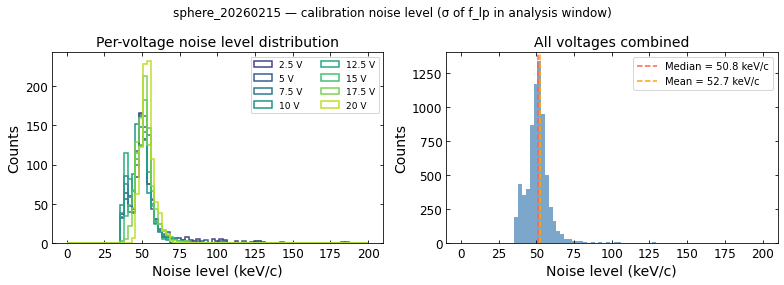

In [7]:
# Plot the noise level distribution from calibration data
noise_level_lists = [noise_level_all_0, noise_level_all_1, noise_level_all_2, noise_level_all_3]

# Per-voltage: concatenate across datasets
noise_per_voltage = [
    np.concatenate([noise_level_lists[j][i] for j in range(len(datasets_all))]) * amp2kev
    for i in range(len(voltages))
]
cmap = plt.colormaps['viridis'] 
### cmap = plt.colormaps.get_cmap('viridis') outdated feature, removed in Matplotlib 3.9.
colors = cmap(np.linspace(0.2, 0.9, 8))

bins = np.linspace(0, 200, 80)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for vi, (nl, v) in enumerate(zip(noise_per_voltage, voltages)):
    axes[0].hist(nl, bins=bins, color=colors[vi], histtype='step', linewidth=1.5, label=f'{v} V')

axes[0].set_xlabel('Noise level (keV/c)')
axes[0].set_ylabel('Counts')
axes[0].set_title('Per-voltage noise level distribution')
axes[0].legend(ncol=2, fontsize=9)

all_nl = np.concatenate(noise_per_voltage)
axes[1].hist(all_nl, bins=bins, color='steelblue', histtype='stepfilled', alpha=0.7)
axes[1].axvline(np.median(all_nl), color='tomato', ls='--', label=f'Median = {np.median(all_nl):.1f} keV/c')
axes[1].axvline(np.mean(all_nl),   color='orange', ls='--', label=f'Mean = {np.mean(all_nl):.1f} keV/c')
axes[1].set_xlabel('Noise level (keV/c)')
axes[1].set_ylabel('Counts')
axes[1].set_title('All voltages combined')
axes[1].legend(fontsize=10)

fig.suptitle(f'{sphere} — calibration noise level (σ of f_lp in analysis window)', fontsize=12)
fig.tight_layout()

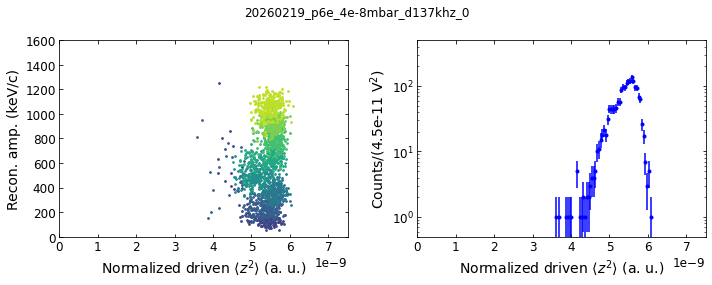

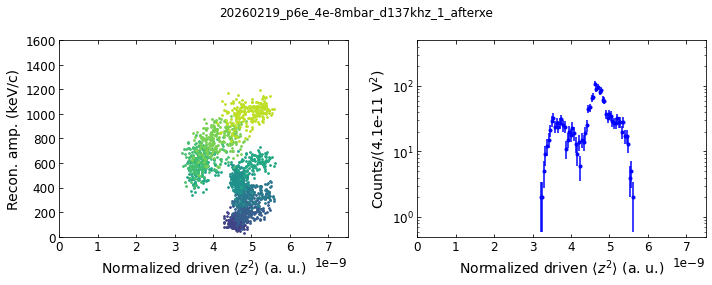

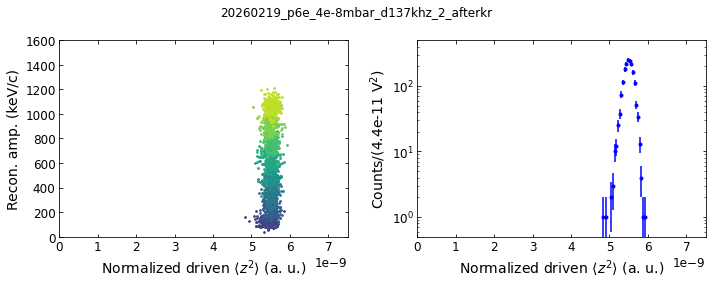

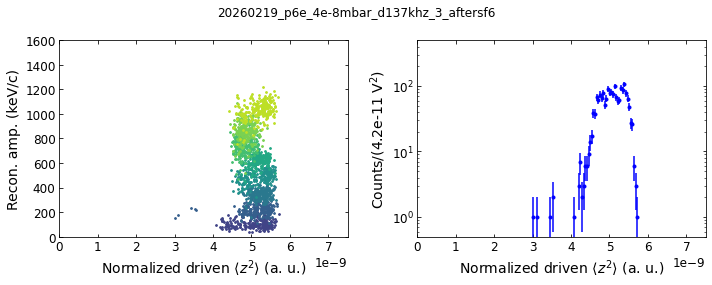

In [8]:
def plot_monitoring(dataset, drive_area_all, amps_all, f_res_all, drive_freq, ref_freq, amp2kev):
    #cmap = plt.colormaps.get_cmap('viridis') outdated feature, removed in Matplotlib 3.9.
    cmap = plt.colormaps['viridis'] 
    colors = cmap(np.linspace(0.2, 0.9, 8))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for i in range(8):
        norm = drive_area_all[i] * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        axes[0].plot(norm, amps_all[i]*amp2kev, '.', color=colors[i], markersize=3.5)

    _drive = np.concatenate(drive_area_all)
    _freq = np.concatenate(f_res_all)

    drive_freq = 137000
    ref_freq = 48500
    normalized_drive_area = _drive * (_freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)

    bins = np.linspace(0, normalized_drive_area.max() * 1.1, 150)
    bc = 0.5 * (bins[1:] + bins[:-1])

    hh, _ = np.histogram(normalized_drive_area, bins=bins)
    axes[1].errorbar(bc, hh, yerr=np.sqrt(hh), fmt='.', color='b', alpha=1)

    axes[0].set_xlim(0, 2e-8)
    axes[0].set_ylim(0, 1600)
    axes[0].set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a. u.)')
    axes[0].set_ylabel(r'Recon. amp. (keV/c)')

    axes[1].set_ylim(5e-1, 5e2)
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a. u.)')
    axes[1].set_ylabel(rf'Counts/({bc[1]-bc[0]:.1e} V$^2$)')

    fig.suptitle(dataset, fontsize=12)
    fig.tight_layout()

    return fig, axes, bc, hh

drive_freq = 137000
ref_freq   = 48500

drive_areas = [drive_area_all_0, drive_area_all_1, drive_area_all_2, drive_area_all_3]
amps_lists  = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
f_res_lists = [f_res_all_0, f_res_all_1, f_res_all_2, f_res_all_3]

for dataset, drive_area, amps, f_res in zip(datasets_all, drive_areas, amps_lists, f_res_lists):
    fig, axes, bc, hh = plot_monitoring(dataset, drive_area, amps, f_res, drive_freq, ref_freq, amp2kev)
    for ax in axes:
        ax.set_xlim(0, 0.75e-8)


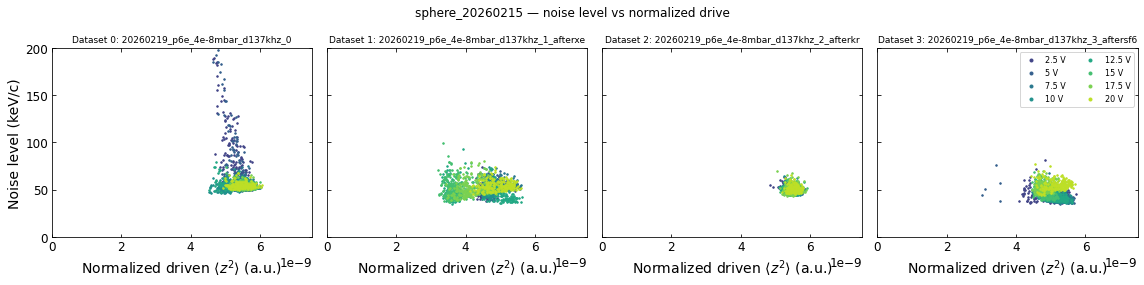

In [9]:
drive_freq = 137000
ref_freq   = 48500

noise_level_lists = [noise_level_all_0, noise_level_all_1, noise_level_all_2, noise_level_all_3]
drive_areas       = [drive_area_all_0,  drive_area_all_1,  drive_area_all_2,  drive_area_all_3]
f_res_lists       = [f_res_all_0,       f_res_all_1,       f_res_all_2,       f_res_all_3]

#cmap = plt.colormaps.get_cmap('viridis') outdated feature, removed in Matplotlib 3.9.
cmap = plt.colormaps['viridis'] 
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, axes = plt.subplots(1, len(datasets_all), figsize=(4 * len(datasets_all), 4), sharey=True)

for j, (ax, dataset, drive_area_all, f_res_all, noise_level_all) in enumerate(zip(
        axes, datasets_all, drive_areas, f_res_lists, noise_level_lists)):

    for i in range(8):
        norm = drive_area_all[i] * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        ax.plot(norm, noise_level_all[i] * amp2kev, '.', color=colors[i],
                markersize=3, label=f'{voltages[i]} V')

    ax.set_xlim(0, 0.75e-8)
    ax.set_ylim(0, 200)
    ax.set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_title(f'Dataset {j}: {dataset}', fontsize=9)

axes[0].set_ylabel('Noise level (keV/c)')
axes[-1].legend(fontsize=8, markerscale=2, ncol=2)
fig.suptitle(f'{sphere} — noise level vs normalized drive', fontsize=12)
fig.tight_layout()

#### Selecting pulses in windows with nice detection and noise level

In [10]:
def get_good_amps(amps_all, pulse_shapes_all, indices_in_win, drive_area_all, f_res_all, noise_level_all,
                  drive_freq, ref_freq, threshold, noise_threshold_kev=70):
    good_amps, good_pulses, good_indices = [], [], []
    for i, drive_area in enumerate(drive_area_all):
        normalized_drive_area = drive_area * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        mask = (normalized_drive_area > threshold) & (noise_level_all[i] * amp2kev < noise_threshold_kev)
        good_amps.append(amps_all[i][mask])
        good_pulses.append(pulse_shapes_all[i][mask])
        good_indices.append(indices_in_win[i][mask])
    return good_amps, good_pulses, good_indices

In [11]:
drive_freq = 137000
ref_freq = 48500
threshold = 4.5e-9
noise_threshold_kev = 100

drive_areas       = [drive_area_all_0,   drive_area_all_1,   drive_area_all_2,   drive_area_all_3]
amps_lists        = [amps_all_0,         amps_all_1,         amps_all_2,         amps_all_3]
pulse_shapes_lists= [pulse_shapes_all_0, pulse_shapes_all_1, pulse_shapes_all_2, pulse_shapes_all_3]
indices_lists     = [indices_0,          indices_1,          indices_2,          indices_3]
f_res_lists       = [f_res_all_0,        f_res_all_1,        f_res_all_2,        f_res_all_3]
noise_level_lists = [noise_level_all_0,  noise_level_all_1,  noise_level_all_2,  noise_level_all_3]

good_amps_all_datasets = []
good_pulses_all_datasets = []
good_indices_all_datasets = []

for amps, pulses, indices, drive_area, f_res, noise_level in zip(
        amps_lists, pulse_shapes_lists, indices_lists, drive_areas, f_res_lists, noise_level_lists):
    good_amps, good_pulses, good_indices = get_good_amps(
        amps, pulses, indices, drive_area, f_res, noise_level, drive_freq, ref_freq, threshold, noise_threshold_kev)
    
    good_amps_all_datasets.append(good_amps)
    good_pulses_all_datasets.append(good_pulses)
    good_indices_all_datasets.append(good_indices)

for j, dataset in enumerate(datasets_all):
    counts = [len(g) for g in good_amps_all_datasets[j]]
    total_before = sum(len(amps_lists[j][i]) for i in range(8))
    total_after = sum(counts)
    print(f'{dataset}: {total_after}/{total_before} windows pass ({100*total_after/total_before:.1f}%)')

# Collect all the amplitudes/pulse shapes/indices into arrays
_good_amps_all_datasets = []
_good_pulse_shape_all_datasets = []
_good_indices_all_datasets = []
for i in range(8):
    _amps = np.concatenate([good_amps_all_datasets[j][i] for j in range(4)])
    _pulses = np.concatenate([good_pulses_all_datasets[j][i] for j in range(4)], axis=0)
    _indices = np.concatenate([good_indices_all_datasets[j][i] for j in range(len(datasets_all))], axis=0)
    _good_amps_all_datasets.append(_amps)
    _good_pulse_shape_all_datasets.append(_pulses)
    _good_indices_all_datasets.append(_indices)

good_amps_all_datasets = _good_amps_all_datasets
good_pulse_shape_all_datasets = _good_pulse_shape_all_datasets
good_indices_all_datasets = _good_indices_all_datasets

# ── Apply same quality cuts to noise-only windows ─────────────────────────
_noise_drive_areas  = [noise_drive_area_0,  noise_drive_area_1,  noise_drive_area_2,  noise_drive_area_3]
_noise_f_res        = [noise_f_res_0,        noise_f_res_1,        noise_f_res_2,        noise_f_res_3]
_noise_noise_levels = [noise_noise_level_0,  noise_noise_level_1,  noise_noise_level_2,  noise_noise_level_3]
_noise_amps         = [amps_noise_0,          amps_noise_1,          amps_noise_2,          amps_noise_3]
_noise_amps_search  = [amps_noise_search_0,   amps_noise_search_1,   amps_noise_search_2,   amps_noise_search_3]
_noise_wfs          = [noise_waveforms_0,      noise_waveforms_1,      noise_waveforms_2,      noise_waveforms_3]
_noise_wfs_search   = [noise_waveforms_search_0, noise_waveforms_search_1,
                       noise_waveforms_search_2, noise_waveforms_search_3]

def _make_noise_mask(drive_area, f_res, noise_level):
    if drive_area is None or f_res is None or noise_level is None:
        return None
    norm_drive = drive_area * (f_res**2 - drive_freq**2)**2 / (ref_freq**2 - drive_freq**2)**2
    return (norm_drive > threshold) & (noise_level * amp2kev < noise_threshold_kev)

noise_masks = [_make_noise_mask(da, fr, nl)
               for da, fr, nl in zip(_noise_drive_areas, _noise_f_res, _noise_noise_levels)]

def _masked_concat(arrays, masks):
    parts = [a[m] for a, m in zip(arrays, masks) if a is not None and m is not None]
    return np.concatenate(parts, axis=0) if parts else None

good_noise_amps            = _masked_concat(_noise_amps,        noise_masks)
good_noise_amps_search     = _masked_concat(_noise_amps_search, noise_masks)
good_noise_waveforms       = _masked_concat(_noise_wfs,         noise_masks)
good_noise_waveforms_search= _masked_concat(_noise_wfs_search,  noise_masks)

n_noise_before = sum(len(a) for a in _noise_amps if a is not None)
n_noise_after  = len(good_noise_amps) if good_noise_amps is not None else 0
print(f'\nNoise windows: {n_noise_after}/{n_noise_before} pass cuts')

20260219_p6e_4e-8mbar_d137khz_0: 1663/1761 windows pass (94.4%)
20260219_p6e_4e-8mbar_d137khz_1_afterxe: 1155/1762 windows pass (65.6%)
20260219_p6e_4e-8mbar_d137khz_2_afterkr: 1763/1763 windows pass (100.0%)
20260219_p6e_4e-8mbar_d137khz_3_aftersf6: 1716/1760 windows pass (97.5%)

Noise windows: 735/876 pass cuts


Noise level (after cuts, no search): 47.9 keV/c
Noise level (after cuts, searched): 90.7 keV/c
amp2keV: 10497.21911865551


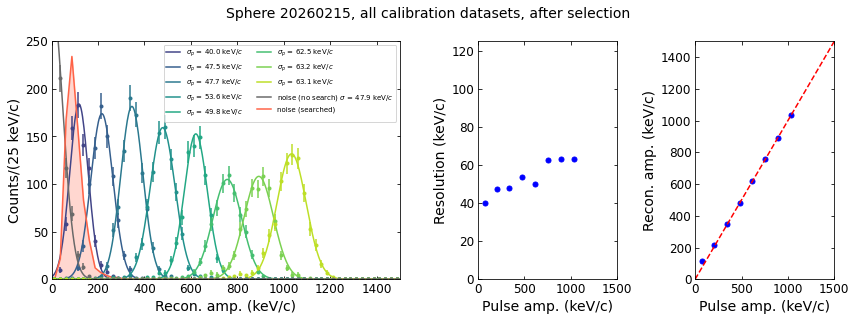

In [12]:
from scipy.optimize import curve_fit

def model_func(x, a):
    return a * x

amp2kev_bin = 10497
bins = np.arange(0, 3000, 25) / amp2kev_bin
pulse_amp = np.asarray([74, 207, 339, 479, 614, 758, 895, 1038])

cmap = plt.colormaps['viridis'] 
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), gridspec_kw={'width_ratios':[2.5, 1, 1]})
hhs_good, bcs_good, gps_good = utils.fit_amps_gaus(good_amps_all_datasets, bins=bins, noise=False, return_bins=False)

xx = np.linspace(0, np.max(bcs[0]), 1000)
for i in range(8):
    axes[0].errorbar(bcs_good[i]*amp2kev_bin, hhs_good[i], yerr=np.sqrt(hhs_good[i]), fmt='.', color=colors[i])
    axes[0].plot(xx*amp2kev_bin, utils.gauss(xx, *gps_good[i]), label=fr'$\sigma_p$ = {gps_good[i][2]*amp2kev_bin:.1f} keV/$c$', color=colors[i])

# Noise amplitude without search — same errorbar+line style as signal
if good_noise_amps is not None and len(good_noise_amps) > 0:
    try:
        hhs_n, bcs_n, gps_n = utils.fit_amps_gaus(
            [good_noise_amps], bins=bins, noise=True, return_bins=False)
        axes[0].errorbar(bcs_n[0]*amp2kev_bin, hhs_n[0], yerr=np.sqrt(hhs_n[0]),
                         fmt='.', color='dimgray')
        axes[0].plot(xx*amp2kev_bin, utils.gauss_zero(xx, *gps_n[0]),
                     color='dimgray',
                     label=fr'noise (no search) $\sigma$ = {gps_n[0][1]*amp2kev_bin:.1f} keV/$c$')
        print(f'Noise level (after cuts, no search): {gps_n[0][1]*amp2kev_bin:.1f} keV/c')
    except Exception as e:
        print(f'Noise (no search) fit failed: {e}')

# Noise amplitude with search — line through bin centers with filled area
if good_noise_amps_search is not None and len(good_noise_amps_search) > 0:
    try:
        hhs_ns, bcs_ns, gps_ns = utils.fit_amps_gaus(
            [good_noise_amps_search], bins=bins, noise=False, return_bins=False)
        xc = bcs_ns[0] * amp2kev_bin
        axes[0].plot(xc, hhs_ns[0], color='tomato', lw=1.5,
                     label=fr'noise (searched)')
        axes[0].fill_between(xc, hhs_ns[0], color='tomato', alpha=0.25)
        print(f'Noise level (after cuts, searched): {gps_ns[0][1]*amp2kev_bin:.1f} keV/c')
    except Exception as e:
        print(f'Noise (searched) fit failed: {e}')

amp2kevs = pulse_amp / np.asarray(gps_good).T[1]
amp2kev = curve_fit(model_func, np.asarray(gps_good).T[1][2:], pulse_amp[2:])[0][0]
print(f'amp2keV: {amp2kev}')

axes[0].legend(ncol=2, fontsize=7)
axes[0].set_xlim(0, 1500)
axes[0].set_ylim(0, 250)
axes[0].set_xlabel('Recon. amp. (keV/c)')
axes[0].set_ylabel('Counts/(25 keV/c)')

axes[1].plot(pulse_amp, np.asarray(gps_good).T[2]*amp2kev, 'b.', markersize=10)
axes[1].set_xlim(0, 1500)
axes[1].set_ylim(0, 125)
axes[1].set_xlabel('Pulse amp. (keV/c)')
axes[1].set_ylabel('Resolution (keV/c)')

axes[2].plot(pulse_amp, np.asarray(gps_good).T[1]*amp2kev, 'b.', markersize=10)
axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
axes[2].set_xlim(0, 1500)
axes[2].set_ylim(0, 1500)
axes[2].set_xlabel('Pulse amp. (keV/c)')
axes[2].set_ylabel('Recon. amp. (keV/c)')

fig.suptitle('Sphere 20260215, all calibration datasets, after selection', fontsize=14)
fig.tight_layout()

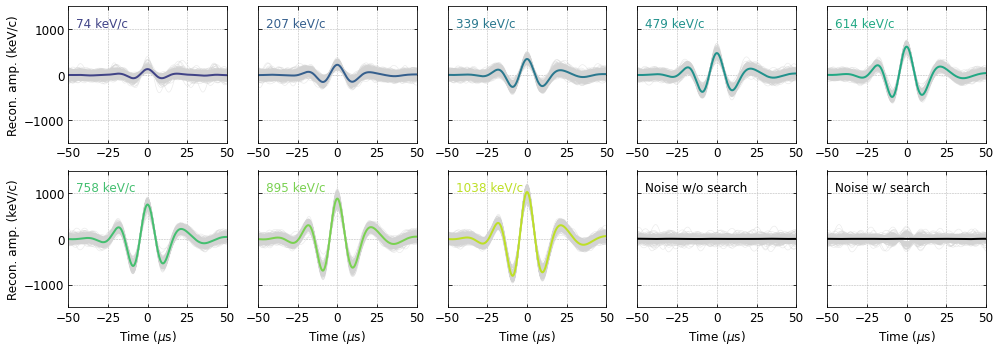

In [13]:
## Form templates by averaging the reconstructed waveform
pulse_shape_template_all = [np.mean(pulses, axis=0) for pulses in good_pulse_shape_all_datasets]
tt = 200e-9 * np.arange(3000)

# 8 voltage panels + 2 noise panels (no-search and searched) → 2×5
fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=True)

for i, (ax, good_pulse) in enumerate(zip(axes.flatten()[:8], good_pulse_shape_all_datasets)):
    for j in range(good_pulse.shape[0]):
        ax.plot(tt/1e-6 - 300, amp2kev * good_pulse[j], color='lightgray', alpha=0.5, lw=0.6)
    ax.plot(tt/1e-6 - 300, amp2kev * np.mean(good_pulse, axis=0), color=colors[i], lw=2)
    ax.text(0.05, 0.85, f'{pulse_amp[i]} keV/c', fontsize=12, color=colors[i],
            transform=ax.transAxes)
    ax.set_xlim(-50, 50)
    ax.set_ylim(-1500, 1500)
    ax.tick_params(labelsize=12)
    ax.grid(linestyle='--', lw=0.5)

def _plot_noise_panel(ax, wf, label):
    if wf is not None and len(wf) > 0:
        for j in range(min(wf.shape[0], 200)):
            ax.plot(tt/1e-6 - 300, amp2kev * wf[j], color='lightgray', alpha=0.5, lw=0.6)
        ax.plot(tt/1e-6 - 300, amp2kev * wf.mean(axis=0), color='k', lw=2)
        ax.text(0.05, 0.85, f'{label}', fontsize=12, color='k',
                transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, f'{label}\n(no data)', fontsize=9, ha='center', va='center',
                transform=ax.transAxes)
    ax.set_xlim(-50, 50)
    ax.set_ylim(-1500, 1500)
    ax.tick_params(labelsize=12)
    ax.grid(linestyle='--', lw=0.5)

_plot_noise_panel(axes.flatten()[8], good_noise_waveforms, 'Noise w/o search')
_plot_noise_panel(axes.flatten()[9], good_noise_waveforms_search, 'Noise w/ search')

for ax in axes[1]:
    ax.set_xlabel(r'Time ($\mu$s)', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r'Recon. amp. (keV/c)', fontsize=12)

fig.tight_layout()

plt.savefig('/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/plots/sup_calibration_waveforms.pdf', dpi=600, bbox_inches='tight')
plt.show()



# Timing resolution 
attempts at getting peak times from the plots above. I try to find the maximum amplitude for each individual impulse and plot the histogram in the next cell

I measured the timing before alignment using recon_pulse. It measures the peak timing relative to the trigger. Peak timing is unalinged before processing. Only become aligned during plotting for the sake of making a template. Since I dont care about making a template, i plot the peak delay distribution relative to the trigger, making the width of the histogram representative of my timing resolution. 

In [14]:
file = rf'/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/data_processed/pulse_calibration/{sphere}/{dataset}_processed.hdf5'
f = h5py.File(file, 'r')

In [15]:
####code below works but it only reads the last datafile of 20 V (1038 kev/c)

# peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]


# ###time to plot (fingers crossed)
# plt.hist(peak_times, bins=30)
# plt.xlabel("Peak time after trigger (µs)")
# plt.ylabel("Counts")
# np.mean(peak_times), np.std(peak_times) ### mean should be a few us, std is the rough timing spread
# plt.title(f"{v} V")
# plt.show()

# print(peak_times.shape)
# print(np.mean(peak_times), np.std(peak_times))

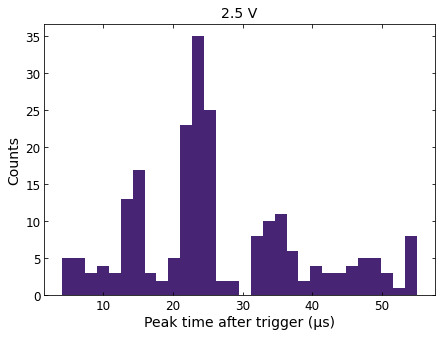

(220,)
26.568181818181817 12.276314458917014


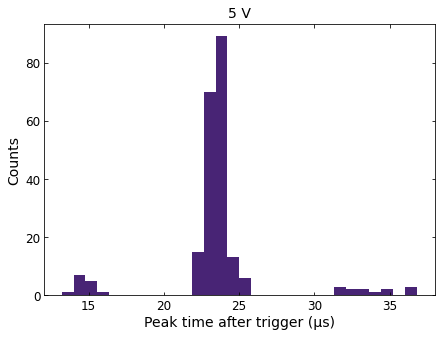

(220,)
23.61727272727273 3.4505693625284266


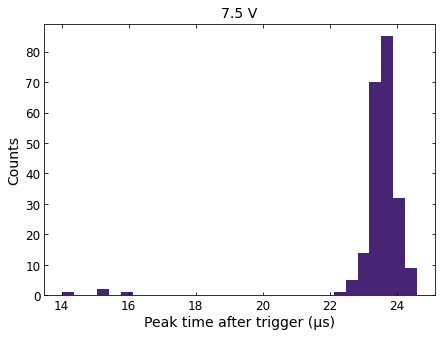

(220,)
23.432727272727274 1.1975815850674065


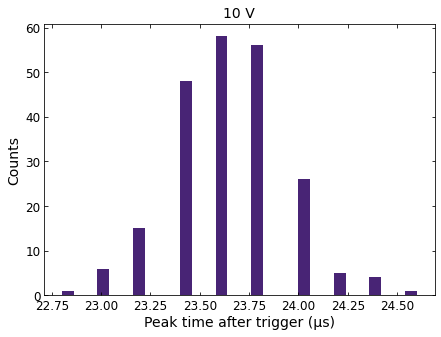

(220,)
23.640000000000004 0.2902036902215093


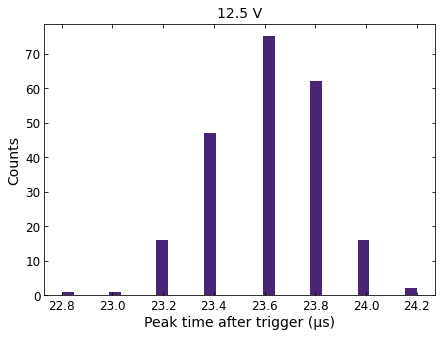

(220,)
23.612727272727277 0.22527118643540855


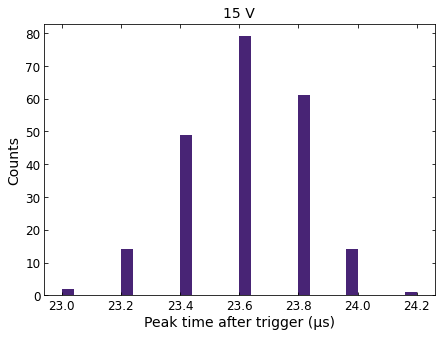

(220,)
23.608181818181823 0.21261652128648664


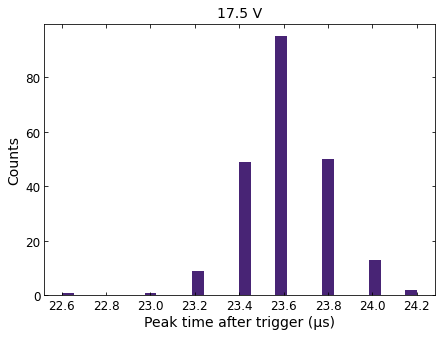

(220,)
23.606363636363643 0.20836038391876932


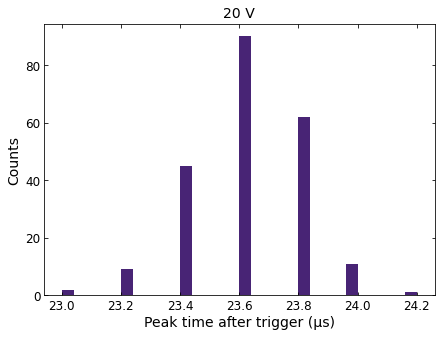

(220,)
23.616363636363637 0.1965739614344934


In [16]:
voltages = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
energies = [74, 207, 339, 479, 614, 758, 895, 1038]  # keV/c
# cmap = plt.colormaps['viridis']
# colors = cmap(np.linspace(0.1, 0.95, len(voltages)))

for v in voltages:
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    plt.figure()
    plt.hist(peak_times, bins=30) ####peak timing is unalinged before processing. Only become aligned during plotting. 
    ####recon_pulse measures the peak timing relative to the trigger, while get_pulse_shape shifts the max amplitude to 0
    plt.title(f"{v} V")
    plt.xlabel("Peak time after trigger (µs)")
    plt.ylabel("Counts")
    plt.show()
    print(peak_times.shape)
    print(np.mean(peak_times), np.std(peak_times)) ###means are systematic delays, std is the timing resolution
    

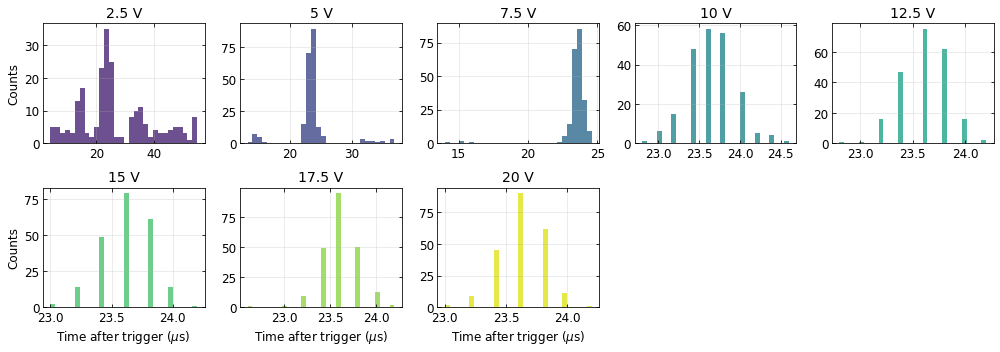

In [17]:
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.1, 0.95, len(voltages)))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))

for i, (ax, v) in enumerate(zip(axes.flatten()[:8], voltages)):
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    ax.hist(peak_times, bins=30, color=colors[i], alpha=0.8)
    ax.set_title(f"{v} V")
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel(r'Time after trigger ($\mu$s)', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r'Counts', fontsize=12)

# (optional) leave last two panels blank or for noise later
axes.flatten()[8].axis('off')
axes.flatten()[9].axis('off')

plt.tight_layout()
plt.show()

####below does the same thing as above, but spits out the histograms individually instead of all in one go
# for i, v in enumerate(voltages):
#     peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

#     plt.figure()
#     plt.hist(peak_times, bins=30, color=colors[i], alpha=0.8)

#     plt.title(f"{v} V")
#     plt.xlabel("Peak time after trigger (µs)")
#     plt.ylabel("Counts")

#     plt.grid(alpha=0.3)
#     plt.show()

In [18]:
####below does the same thing as the next cell, but spits out the histograms individually instead of all in one go
# for i, (v, E) in enumerate(zip(voltages, energies)):
#     peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

#     plt.figure()
#     plt.hist(peak_times, bins=30, color=colors[i], alpha=0.8)

#     plt.title(f"{E} keV/c")
#     plt.xlabel("Peak time after trigger (µs)")
#     plt.ylabel("Counts")
#     plt.grid(alpha=0.3)

#     plt.show()

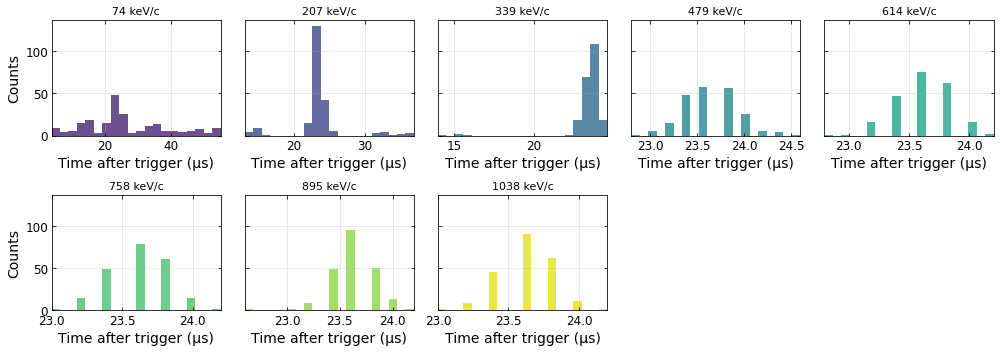

In [19]:
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.1, 0.95, len(voltages)))

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=True)

for i, (ax, v, E) in enumerate(zip(axes.flatten()[:8], voltages, energies)):
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    ax.hist(peak_times, bins=20, color=colors[i], alpha=0.8)
    ax.set_title(f"{E} keV/c", fontsize=11)

    ax.set_xlabel("Time after trigger (µs)")
    ax.set_xlim(min(peak_times), max(peak_times))
    ax.grid(alpha=0.3)

# Leave last two panels for noise (optional later)
axes.flatten()[8].axis('off')
axes.flatten()[9].axis('off')

axes[0,0].set_ylabel("Counts")
axes[1,0].set_ylabel("Counts")

plt.tight_layout()
plt.show()

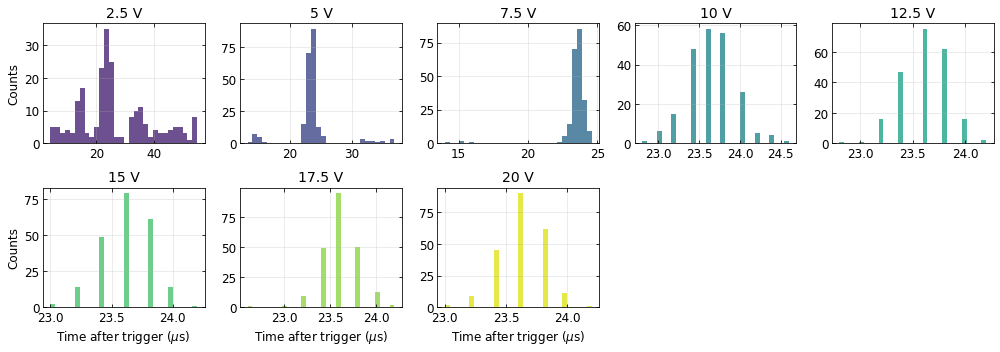

In [20]:
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0.1, 0.95, len(voltages)))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))

for i, (ax, v) in enumerate(zip(axes.flatten()[:8], voltages)):
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    ax.hist(peak_times, bins=30, color=colors[i], alpha=0.8)
    ax.set_title(f"{v} V")
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel(r'Time after trigger ($\mu$s)', fontsize=12)
for ax in axes[:, 0]:
    ax.set_ylabel(r'Counts', fontsize=12)

# (optional) leave last two panels blank or for noise later
axes.flatten()[8].axis('off')
axes.flatten()[9].axis('off')

plt.tight_layout()
plt.show()

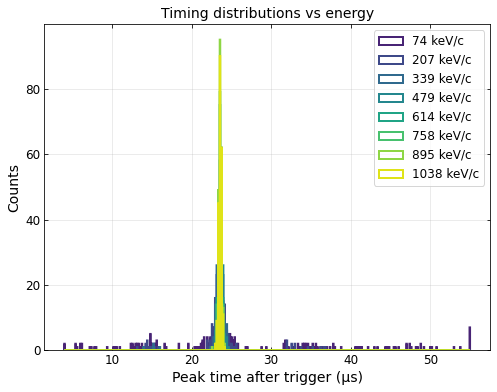

In [21]:
all_peak_times = []

for v in voltages:
    pt = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]
    all_peak_times.append(pt)

all_peak_times = np.concatenate(all_peak_times)

bins = np.histogram_bin_edges(all_peak_times, bins='fd')
plt.figure(figsize=(8,6))

for i, (v, E) in enumerate(zip(voltages, energies)):
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    plt.hist(
        peak_times,
        bins=bins,
        histtype='step',   # important for overlay
        linewidth=2,
        color=colors[i],
        label=f"{E} keV/c"
    )

plt.xlabel("Peak time after trigger (µs)")
plt.ylabel("Counts")
plt.title("Timing distributions vs energy")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

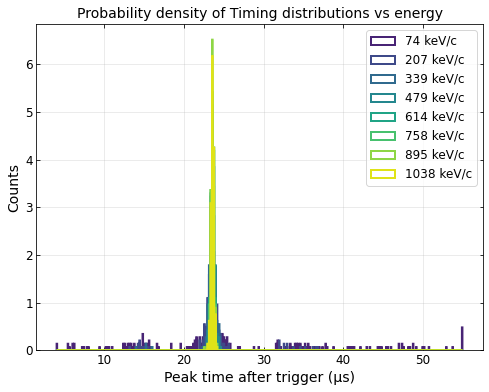

In [22]:
all_peak_times = []

for v in voltages:
    pt = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]
    all_peak_times.append(pt)

all_peak_times = np.concatenate(all_peak_times)

bins = np.histogram_bin_edges(all_peak_times, bins='fd')
plt.figure(figsize=(8,6))

for i, (v, E) in enumerate(zip(voltages, energies)):
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    plt.hist(
        peak_times,
        bins=bins,
        histtype='step',
        linewidth=2,
        color=colors[i],
        label=f"{E} keV/c",
        density=True
    )

plt.xlabel("Peak time after trigger (µs)")
plt.ylabel("Counts")
plt.title("Probability density of Timing distributions vs energy")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

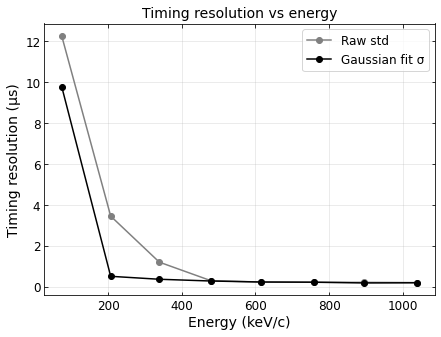

In [23]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

sigmas_fit = []
sigmas_std = []
means_fit = []

for v in voltages:
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

    # Histogram (use SAME bins as before!)
    counts, edges = np.histogram(peak_times, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Initial guesses (important for stability)
    A0 = counts.max()
    mu0 = np.mean(peak_times)
    sigma0 = np.std(peak_times)

    try:
        popt, _ = curve_fit(gaussian, centers, counts, p0=[A0, mu0, sigma0])
        A_fit, mu_fit, sigma_fit = popt
    except RuntimeError:
        print(f"Fit failed for {v} V")
        A_fit, mu_fit, sigma_fit = np.nan, np.nan, np.nan

    # Store results
    sigmas_fit.append(sigma_fit)
    sigmas_std.append(np.std(peak_times))
    means_fit.append(mu_fit)
    
plt.figure()

plt.plot(energies, sigmas_std, 'o-', label='Raw std', color='gray')
plt.plot(energies, sigmas_fit, 'o-', label='Gaussian fit σ', color='black')

plt.xlabel("Energy (keV/c)")
plt.ylabel("Timing resolution (µs)")
plt.title("Timing resolution vs energy")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

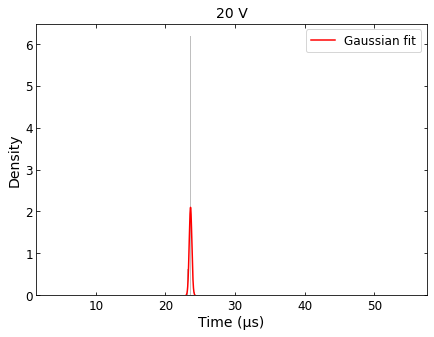

In [24]:
v = 20
peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]

counts, edges = np.histogram(peak_times, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

popt, _ = curve_fit(gaussian, centers, counts, p0=[counts.max(), np.mean(peak_times), np.std(peak_times)])

x_fit = np.linspace(min(peak_times), max(peak_times), 500)
y_fit = gaussian(x_fit, *popt)

plt.figure()
plt.hist(peak_times, bins=bins, density=True, alpha=0.5, color='gray')
plt.plot(x_fit, y_fit, 'r-', label='Gaussian fit')

plt.xlabel("Time (µs)")
plt.ylabel("Density")
plt.title(f"{v} V")
plt.legend()
plt.show()

<Figure size 504x360 with 0 Axes>

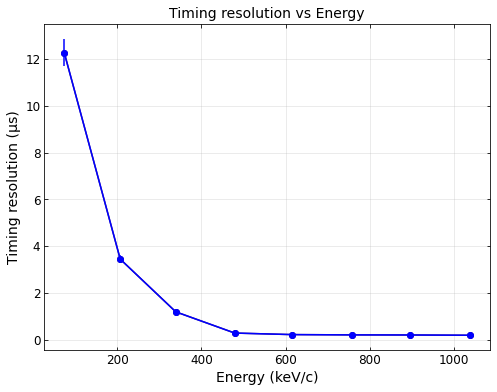

In [25]:
means = []
stds = []

for v in voltages:
    peak_times = f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]
    
    means.append(np.mean(peak_times))
    stds.append(np.std(peak_times))
####makes the same plot as below, but as a function of impulse voltage instead of energy. Also doesnt have the error bars    
# plt.figure(figsize=(8,6))
# plt.plot(voltages, stds, 'o-')
# plt.xlabel("Voltage (V)")
# plt.ylabel("Timing resolution (µs)")
# plt.title("Timing resolution vs Impulse voltage")
# plt.rcParams.update({'font.size': 12})
# plt.grid(alpha=0.3)
# plt.show()



plt.figure()
plt.figure(figsize=(8,6))
plt.plot(energies, stds, 'o-')
errors = [np.std(f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:]) / np.sqrt(2*len(f['data_processed'][f'peak_times_from_trigger_us_{v}v'][:])) for v in voltages]

plt.errorbar(energies, stds, yerr=errors, fmt='o-', color='blue')
plt.xlabel("Energy (keV/c)")
plt.ylabel("Timing resolution (µs)")
plt.title("Timing resolution vs Energy")
plt.rcParams.update({'font.size': 12})
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Save the averaged calibration waveform as template, plus all individual waveforms after selection
_save_kwargs = dict(
    ps_2_5v=pulse_shape_template_all[0],
    ps_5v=pulse_shape_template_all[1],
    ps_7_5v=pulse_shape_template_all[2],
    ps_10v=pulse_shape_template_all[3],
    ps_12_5v=pulse_shape_template_all[4],
    ps_15v=pulse_shape_template_all[5],
    ps_17_5v=pulse_shape_template_all[6],
    ps_20v=pulse_shape_template_all[7],
    pulse_amp_kev=pulse_amp,
    amp2kev=amp2kev,
    
    # Individual waveforms (N_pulses, 3000) used to form each template
    ind_2_5v=good_pulse_shape_all_datasets[0],
    ind_5v=good_pulse_shape_all_datasets[1],
    ind_7_5v=good_pulse_shape_all_datasets[2],
    ind_10v=good_pulse_shape_all_datasets[3],
    ind_12_5v=good_pulse_shape_all_datasets[4],
    ind_15v=good_pulse_shape_all_datasets[5],
    ind_17_5v=good_pulse_shape_all_datasets[6],
    ind_20v=good_pulse_shape_all_datasets[7],
    
    # Reconstructed amplitudes (N_pulses,) for each voltage
    amp_2_5v=good_amps_all_datasets[0],
    amp_5v=good_amps_all_datasets[1],
    amp_7_5v=good_amps_all_datasets[2],
    amp_10v=good_amps_all_datasets[3],
    amp_12_5v=good_amps_all_datasets[4],
    amp_15v=good_amps_all_datasets[5],
    amp_17_5v=good_amps_all_datasets[6],
    amp_20v=good_amps_all_datasets[7],

    # Pulse timing indices in window (N_pulses,) for each voltage
    idx_2_5v=good_indices_all_datasets[0],
    idx_5v=good_indices_all_datasets[1],
    idx_7_5v=good_indices_all_datasets[2],
    idx_10v=good_indices_all_datasets[3],
    idx_12_5v=good_indices_all_datasets[4],
    idx_15v=good_indices_all_datasets[5],
    idx_17_5v=good_indices_all_datasets[6],
    idx_20v=good_indices_all_datasets[7],
)

# Noise waveforms after quality cuts (from 2.5 V windows)
if good_noise_waveforms is not None:
    _save_kwargs['noise_waveforms'] = good_noise_waveforms
    _save_kwargs['noise_amps'] = good_noise_amps
if good_noise_waveforms_search is not None:
    _save_kwargs['noise_waveforms_search'] = good_noise_waveforms_search
    _save_kwargs['noise_amps_search'] = good_noise_amps_search

np.savez(
    rf'/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/data_processed/pulse_calibration/{sphere}/sphere_20260215_impulse_recon_combined.npz',
    **_save_kwargs,
)

In [ ]:
# ── Chi2 vs amplitude, impulse calibration datasets ──────────────────────
# Consistent with calc_chisquares() in process_gas_data.py:
#   chi2 = sum( ((waveform - amp * T_norm) / sigma_amp)^2 )
#   sigma_amp = 60 keV / amp2kev  (raw units)
#   window = template_half_len (250) samples each side of peak
#
# Polarity: signal pulse_shapes are polarity-corrected by get_pulse_shape()
# (always positive at centre). Noise waveforms are raw f_lp slices with no
# polarity correction, but their stored amplitudes are absolute values.
# We apply sign(waveform[centre]) before computing noise chi2 so the
# template comparison is consistent with the signal convention.

template_half_len_chi2 = 250                                   # must match process_gas_data.py
T_norm    = pulse_shape_template_all[-1] / pulse_shape_template_all[-1].max()  # unit-peak
sigma_amp = 60 / amp2kev                                       # 60 keV/c in raw units

chi2_sl = slice(1500 - template_half_len_chi2, 1500 + template_half_len_chi2)  # 500-sample window

chi2_by_v = []
amp_by_v  = []
for vi in range(len(voltages)):
    shapes = good_pulse_shape_all_datasets[vi]   # (N, 3000) raw units, polarity-corrected
    amps   = good_amps_all_datasets[vi]           # (N,) raw units, absolute value
    template_scaled = amps[:, None] * T_norm[chi2_sl]
    resid  = shapes[:, chi2_sl] - template_scaled
    chi2   = np.sum((resid / sigma_amp)**2, axis=1)
    chi2_by_v.append(chi2)
    amp_by_v.append(amps * amp2kev)

# ── Noise chi2 — no-search (waveform centred at midpoint) ─────────────────
# Apply polarity from waveform centre (index 1500) to match signal convention.
if good_noise_waveforms is not None and good_noise_amps is not None:
    _pol = np.sign(good_noise_waveforms[:, 1500:1501])         # (N, 1), ±1
    _wf  = good_noise_waveforms * _pol                         # polarity-corrected
    _tpl = good_noise_amps[:, None] * T_norm[chi2_sl]
    noise_chi2_nosearch     = np.sum(((_wf[:, chi2_sl] - _tpl) / sigma_amp)**2, axis=1)
    noise_amps_kev_nosearch = good_noise_amps * amp2kev
else:
    noise_chi2_nosearch = None
    noise_amps_kev_nosearch = None

# ── Noise chi2 — searched (waveform centred at searched peak) ─────────────
# Centre is also at index 1500; apply same polarity correction.
if good_noise_waveforms_search is not None and good_noise_amps_search is not None:
    _pol = np.sign(good_noise_waveforms_search[:, 1500:1501])  # (N, 1), ±1
    _wf  = good_noise_waveforms_search * _pol
    _tpl = good_noise_amps_search[:, None] * T_norm[chi2_sl]
    noise_chi2_search     = np.sum(((_wf[:, chi2_sl] - _tpl) / sigma_amp)**2, axis=1)
    noise_amps_kev_search = good_noise_amps_search * amp2kev
else:
    noise_chi2_search = None
    noise_amps_kev_search = None

# ── Plot ──────────────────────────────────────────────────────────────────
_vc = plt.colormaps['viridis'](np.linspace(0.2, 0.9, len(voltages)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter + 1σ ellipses + noise overlay
from matplotlib.patches import Ellipse
ax = axes[0]
for vi, (chi2, amps_kev) in enumerate(zip(chi2_by_v, amp_by_v)):
    ax.plot(amps_kev, chi2, '.', color=_vc[vi], markersize=3, alpha=0.3)
    mu_a, sig_a = np.mean(amps_kev), np.std(amps_kev)
    mu_c, sig_c = np.mean(chi2),     np.std(chi2)
    ell = Ellipse((mu_a, mu_c), width=2*sig_a, height=2*sig_c,
                  facecolor='none', edgecolor=_vc[vi], lw=1.5)
    ax.add_patch(ell)
    ax.plot(mu_a, mu_c, 'o', color=_vc[vi], markersize=5,
            markeredgecolor='k', markeredgewidth=0.5, label=f'{voltages[vi]} V')

if noise_chi2_nosearch is not None:
    ax.plot(noise_amps_kev_nosearch, noise_chi2_nosearch, 'x', color='dimgray',
            markersize=4, alpha=0.5, label=f'noise no-search (N={len(noise_chi2_nosearch)})')
    mu_a, sig_a = np.mean(noise_amps_kev_nosearch), np.std(noise_amps_kev_nosearch)
    mu_c, sig_c = np.mean(noise_chi2_nosearch),     np.std(noise_chi2_nosearch)
    ell = Ellipse((mu_a, mu_c), width=2*sig_a, height=2*sig_c,
                  facecolor='none', edgecolor='dimgray', lw=1.5, ls='--')
    ax.add_patch(ell)
    ax.plot(mu_a, mu_c, 'o', color='dimgray', markersize=5,
            markeredgecolor='k', markeredgewidth=0.5)

if noise_chi2_search is not None:
    ax.plot(noise_amps_kev_search, noise_chi2_search, '+', color='tomato',
            markersize=5, alpha=0.5, label=f'noise searched (N={len(noise_chi2_search)})')
    mu_a, sig_a = np.mean(noise_amps_kev_search), np.std(noise_amps_kev_search)
    mu_c, sig_c = np.mean(noise_chi2_search),     np.std(noise_chi2_search)
    ell = Ellipse((mu_a, mu_c), width=2*sig_a, height=2*sig_c,
                  facecolor='none', edgecolor='tomato', lw=1.5, ls='--')
    ax.add_patch(ell)
    ax.plot(mu_a, mu_c, 'o', color='tomato', markersize=5,
            markeredgecolor='k', markeredgewidth=0.5)

ax.set_xlim(0, 1300)
ax.set_ylim(0, 2000)
ax.set_xlabel('Recon. amp. (keV/c)')
ax.set_ylabel(r'$\chi^2$')
ax.set_title('Chi2 vs amplitude (scatter + 1σ ellipses)')
ax.legend(ncol=2, fontsize=7)
ax.grid(which='both', ls=':', lw=0.5)

# Right: chi2 histogram per voltage + both noise variants
ax = axes[1]
all_chi2_vals = list(chi2_by_v)
if noise_chi2_nosearch is not None: all_chi2_vals.append(noise_chi2_nosearch)
if noise_chi2_search   is not None: all_chi2_vals.append(noise_chi2_search)
all_chi2_max = max(np.percentile(c, 99) for c in all_chi2_vals)
bins_c = np.linspace(0, all_chi2_max * 1.1, 60)

for vi, chi2 in enumerate(chi2_by_v):
    ax.hist(chi2, bins=bins_c, color=_vc[vi], histtype='step', lw=1.3,
            label=f'{voltages[vi]} V (med={np.median(chi2):.0f})')
if noise_chi2_nosearch is not None:
    ax.hist(noise_chi2_nosearch, bins=bins_c, color='dimgray', histtype='step', lw=1.5, ls='--',
            label=f'noise no-search (med={np.median(noise_chi2_nosearch):.0f})')
if noise_chi2_search is not None:
    ax.hist(noise_chi2_search, bins=bins_c, color='tomato', histtype='step', lw=1.5, ls='--',
            label=f'noise searched (med={np.median(noise_chi2_search):.0f})')

ax.set_xlabel(r'$\chi^2$')
ax.set_ylabel('Counts')
ax.set_title('Chi2 distribution per voltage')
ax.legend(ncol=2, fontsize=6)
ax.grid(which='both', ls=':', lw=0.5)

# fig.suptitle(f'{sphere} — chi2 vs 20 V template, calibration datasets  (σ = 60 keV/c)', fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# ── Rejection rate at chi2 threshold = 1000 ────────────────────────────────
# For each voltage, compute the fraction of good calibration pulses rejected
# by a chi2 > 1000 cut. Uncertainty from binomial statistics:
#   sigma(p) = sqrt(p*(1-p)/N)

chi2_cut = 1000

print(f'Chi2 threshold: {chi2_cut}')
print(f'{"Voltage":>8s}  {"Amp (keV/c)":>11s}  {"N_total":>7s}  {"N_reject":>8s}  {"Reject %":>9s}  {"± σ (%)":>8s}')
print('-' * 65)

reject_fracs = []
reject_sigmas = []
for vi, (chi2, v) in enumerate(zip(chi2_by_v, voltages)):
    n_tot = len(chi2)
    n_rej = np.sum(chi2 > chi2_cut)
    p_rej = n_rej / n_tot
    sigma_p = np.sqrt(p_rej * (1 - p_rej) / n_tot)
    reject_fracs.append(p_rej)
    reject_sigmas.append(sigma_p)
    print(f'{v:7.1f} V  {pulse_amp[vi]:11.0f}  {n_tot:7d}  {n_rej:8d}  {100*p_rej:8.2f}%  {100*sigma_p:7.2f}%')

# Weighted average rejection rate across all voltages
reject_fracs  = np.array(reject_fracs)
reject_sigmas = np.array(reject_sigmas)
w = 1 / reject_sigmas**2
avg_rej = np.sum(w * reject_fracs) / np.sum(w)
avg_rej_err = np.sqrt(1 / np.sum(w))
print(f'\nWeighted average rejection rate: {100*avg_rej:.2f} ± {100*avg_rej_err:.2f} %')

# ── Noise (searched) rejection rate ──────────────────────────────────────
if noise_chi2_search is not None and len(noise_chi2_search) > 0:
    print()
    print('Noise (searched) events:')
    print(f'{"Label":>20s}  {"N_total":>7s}  {"N_reject":>8s}  {"Reject %":>9s}  {"± σ (%)":>8s}')
    print('-' * 60)
    n_tot  = len(noise_chi2_search)
    n_rej  = np.sum(noise_chi2_search > chi2_cut)
    p_rej  = n_rej / n_tot
    sigma_p = np.sqrt(p_rej * (1 - p_rej) / n_tot)
    print(f'{"noise (searched)":>20s}  {n_tot:7d}  {n_rej:8d}  {100*p_rej:8.2f}%  {100*sigma_p:7.2f}%')

## Gas datasets reconstruction quality

Amplitude distributions, mean waveforms, noise level diagnostics, and quality cuts for the **calibration pulses** embedded in each gas collision dataset (output of `process_gas_data.py --cal`).  
`amp2kev` is set via `fixed_amp2kev` (from impulse calibration) or derived from a Gaussian fit to all combined amplitudes.

In [ ]:
# ── Helper functions ────────────────────────────────────────────────────────

def load_cal_processed(base_dir, data_type, dataset):
    """Load _cal_processed.hdf5 for a gas dataset. Returns dict with arrays."""
    import os, h5py
    path = os.path.join(base_dir, data_type, dataset, f'{dataset}_cal_processed.hdf5')
    if not os.path.exists(path):
        print(f'  Missing: {path}')
        return None
    with h5py.File(path, 'r') as f:
        g = f['data_processed']
        out = {
            'amplitude':       g['amplitude'][:],
            'waveform':        g['waveform'][:],
            'noise_level_amp': g['noise_level_amp'][:],
            'driven_power':    g['driven_power'][:],
            'f_res':           g['f_res'][:],
        }
        if 'fixed_c_imp' in g.attrs:
            out['fixed_c_imp'] = g.attrs['fixed_c_imp']
        elif 'c_imp_scaling' in g.attrs:
            out['c_imp_scaling'] = g.attrs['c_imp_scaling']
    return out

def _fit_gaussian_amp(amps, expected_kev, n_bins=60):
    """Fit Gaussian to amplitude histogram. Returns (bins, hh, gp, a2k)."""
    if len(amps) < 5:
        return None, None, None, None
    bins = np.linspace(0, np.max(amps) * 1.3, n_bins + 1)
    bc   = 0.5 * (bins[:-1] + bins[1:])
    hh, _ = np.histogram(amps, bins=bins)
    gp, a2k = None, None
    try:
        gp, _ = curve_fit(utils.gauss, bc, hh,
                          p0=[hh.max(), np.mean(amps), np.std(amps)],
                          bounds=([0, 0, 0], np.inf), maxfev=10000)
        a2k = expected_kev / gp[1]
    except Exception as e:
        print(f'  Gaussian fit failed: {e}')
    return bins, hh, gp, a2k

def _compute_norm_drive(drv_power, f_res_arr, drive_freq, ref_freq):
    return drv_power * (f_res_arr**2 - drive_freq**2)**2 / (ref_freq**2 - drive_freq**2)**2

def _apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev, drive_cut):
    return (noise_kev < noise_cut_kev) & (norm_drive > drive_cut)

## Time resolution data is all above
DCM thinks I have all the data files I need with the above code. So, we can ignore the rest for now and only work with the above. 


In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────
import os

gas_base_dir     = rf'/Users/jacquelinebaeza-rubio/Downloads/SIMPLE/QuIPS/gas_collisions/data_processed/pulse_calibration/gas_data_processed/{sphere}'
expected_kev_cal = 1038     # expected cal pulse amplitude in keV/c
drive_freq_gas   = 137000
ref_freq_gas     = 48500

# Set to a float to use a fixed amp2kev across all datasets (from impulse calibration).
# Set to None to derive from a Gaussian fit to all combined amplitudes.
fixed_amp2kev = 10497.219118653622

gas_configs = {
    'background': [
        ('20260219_p6e_4e-8mbar',                'background_data'),
        ('20260219_p6e_3e-8mbar_xevalveclosed',  'background_data'),
        ('20260219_p6e_3e-8mbar_krvalveclosed',  'background_data'),
        ('20260219_p6e_3e-8mbar_sf6valveclosed', 'background_data'),
    ],
    'xenon': [
        ('20260219_p6e_1e-6mbar',   'xenon_data'),
        ('20260219_p6e_8e-7mbar',   'xenon_data'),
        ('20260219_p6e_4e-7mbar_1', 'xenon_data'),
        ('20260219_p6e_2e-7mbar',   'xenon_data'),
        ('20260219_p6e_1e-7mbar_1', 'xenon_data'),
        ('20260219_p6e_7e-8mbar',   'xenon_data'),
        ('20260219_p6e_5e-8mbar',   'xenon_data'),
    ],
    'krypton': [
        ('20260219_p6e_1e-6mbar', 'krypton_data'),
        ('20260219_p6e_7e-7mbar', 'krypton_data'),
        ('20260219_p6e_5e-7mbar', 'krypton_data'),
        ('20260219_p6e_2e-7mbar', 'krypton_data'),
        ('20260219_p6e_1e-7mbar', 'krypton_data'),
        ('20260219_p6e_7e-8mbar', 'krypton_data'),
        ('20260219_p6e_5e-8mbar', 'krypton_data'),
    ],
    'sf6': [
        ('20260219_p6e_1e-6mbar',   'sf6_data'),
        ('20260219_p6e_7e-7mbar',   'sf6_data'),
        ('20260219_p6e_5e-7mbar',   'sf6_data'),
        ('20260219_p6e_3e-7mbar_1', 'sf6_data'),
        ('20260219_p6e_1e-7mbar',   'sf6_data'),
        ('20260219_p6e_7e-8mbar',   'sf6_data'),
        ('20260219_p6e_5e-8mbar',   'sf6_data'),
    ],
}

# ── Load all _cal_processed.hdf5 ──────────────────────────────────────────
gas_data = {}   # gas_type → list of dicts (one per dataset, None if missing)
for gas_type, configs in gas_configs.items():
    gas_data[gas_type] = []
    for dataset, data_type in configs:
        d = load_cal_processed(gas_base_dir, data_type, dataset)
        gas_data[gas_type].append(d)

gas_types = list(gas_configs.keys())

# ── amp2kev ───────────────────────────────────────────────────────────────
if fixed_amp2kev is not None:
    amp2kev = fixed_amp2kev
    print(f'amp2kev = {amp2kev:.2f}  (fixed)')
else:
    _all_amps = np.concatenate([d['amplitude'] for dlist in gas_data.values()
                                for d in dlist if d is not None and len(d['amplitude']) > 0])
    _, _, _gp, amp2kev = _fit_gaussian_amp(_all_amps, expected_kev_cal)
    if amp2kev is not None:
        print(f'amp2kev (combined Gaussian fit) = {amp2kev:.2f}')
    else:
        print('Warning: Gaussian fit failed — set fixed_amp2kev manually')

_a2k_label = f'fixed amp2kev = {amp2kev:.0f}' if fixed_amp2kev is not None else 'amp2kev from Gaussian fit'

# ── Figure 1: amplitude histograms, one panel per gas type ───────────────
fig, axes = plt.subplots(1, len(gas_types), figsize=(5 * len(gas_types), 4), sharey=True)
for ax, gas_type in zip(axes, gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    colors = plt.colormaps['plasma'](np.linspace(0.15, 0.85, max(n_ds, 1)))
    for k, (d, (dataset, _)) in enumerate(zip(gas_data[gas_type], configs_for_type)):
        if d is None or len(d['amplitude']) == 0:
            continue
        amps_kev = d['amplitude'] * amp2kev
        bins = np.linspace(0, max(amps_kev.max() * 1.2, 2000), 61)
        hh, edges = np.histogram(amps_kev, bins=bins)
        lbl = dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset
        ax.stairs(hh, edges=edges, color=colors[k], lw=1.2, label=lbl)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_title(gas_type, fontsize=10)
    ax.set_xlim(0, 2500)
    ax.legend(fontsize=6)
    ax.grid(which='both', ls=':', lw=0.5)
axes[0].set_ylabel('Counts / bin')
fig.suptitle(f'{sphere} — cal pulse amplitude distributions, gas datasets ({_a2k_label})', fontsize=11)
fig.tight_layout()
plt.show()

# ── Figure 2: mean waveforms, one panel per gas type ─────────────────────
tt_us = 200e-9 * np.arange(3000) / 1e-6 - 300   # µs, centred on pulse peak
fig, axes = plt.subplots(1, len(gas_types), figsize=(5 * len(gas_types), 4), sharey=True)
for ax, gas_type in zip(axes, gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    colors = plt.colormaps['plasma'](np.linspace(0.15, 0.85, max(n_ds, 1)))
    for k, (d, (dataset, _)) in enumerate(zip(gas_data[gas_type], configs_for_type)):
        if d is None or len(d['waveform']) == 0:
            continue
        wavs_kev = d['waveform'] * amp2kev
        lbl = f"{dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset} (N={len(wavs_kev)})"
        ax.plot(tt_us, wavs_kev.mean(axis=0), color=colors[k], lw=1.2, label=lbl)
    ax.axvline(0, color='k', ls=':', lw=0.8)
    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.set_xlim(-150, 150)
    ax.set_xlabel(r'Time ($\mu$s)')
    ax.set_title(gas_type, fontsize=10)
    ax.legend(fontsize=6)
    ax.grid(which='both', ls=':', lw=0.5)
axes[0].set_ylabel('Recon. amp. (keV/c)')
fig.suptitle(f'{sphere} — mean cal pulse waveform, gas datasets ({_a2k_label})', fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# ── Noise level vs. normalised driven tone power ──────────────────────────
fig, axes = plt.subplots(1, len(gas_types), figsize=(5 * len(gas_types), 4), sharey=True)
for ax, gas_type in zip(axes, gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    colors = plt.colormaps['plasma'](np.linspace(0.15, 0.85, max(n_ds, 1)))
    for k, (d, (dataset, _)) in enumerate(zip(gas_data[gas_type], configs_for_type)):
        if d is None or len(d['amplitude']) == 0:
            continue
        noise_kev  = d['noise_level_amp'] * amp2kev
        norm_drive = _compute_norm_drive(d['driven_power'], d['f_res'], drive_freq_gas, ref_freq_gas)
        lbl = dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset
        ax.plot(norm_drive, noise_kev, '.', color=colors[k], markersize=3, alpha=0.6, label=lbl)
    ax.set_xlabel(r'Norm. driven $\langle z^2 \rangle$ (a.u.)')
    ax.set_title(gas_type, fontsize=10)
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 6e-9)
    ax.legend(fontsize=6)
    ax.grid(which='both', ls=':', lw=0.5)
axes[0].set_ylabel('Noise level (keV/c)')
fig.suptitle(f'{sphere} — noise level vs. normalised driven power, gas datasets', fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# ── Quality cuts ──────────────────────────────────────────────────────────
noise_cut_kev_gas = 100     # keV/c
drive_cut_gas     = 4.5e-9

print(f'Quality cuts ({_a2k_label}):\n')
for gas_type in gas_types:
    print(f'  {gas_type}:')
    for d, (dataset, _) in zip(gas_data[gas_type], gas_configs[gas_type]):
        lbl = dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset
        if d is None or len(d['amplitude']) == 0:
            print(f'    {lbl}: missing')
            continue
        noise_kev  = d['noise_level_amp'] * amp2kev
        norm_drive = _compute_norm_drive(d['driven_power'], d['f_res'], drive_freq_gas, ref_freq_gas)
        mask       = _apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev_gas, drive_cut_gas)
        amps_raw   = d['amplitude']
        n_bef, n_aft = len(amps_raw), int(mask.sum())
        _, _, gp_bef, _ = _fit_gaussian_amp(amps_raw,        expected_kev_cal)
        _, _, gp_aft, _ = _fit_gaussian_amp(amps_raw[mask],  expected_kev_cal)
        sig_bef = gp_bef[2] * amp2kev if gp_bef is not None else np.nan
        sig_aft = gp_aft[2] * amp2kev if gp_aft is not None else np.nan
        print(f'    {lbl}: {n_aft}/{n_bef} pass cuts,  σ: {sig_bef:.1f} → {sig_aft:.1f} keV/c')

# ── σ resolution summary plot, one panel per gas type ─────────────────────
fig, axes = plt.subplots(1, len(gas_types), figsize=(4 * len(gas_types), 4), sharey=True)
for ax, gas_type in zip(axes, gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    xx = np.arange(n_ds)
    sig_bef_list, sig_aft_list = [], []
    for d, (dataset, _) in zip(gas_data[gas_type], configs_for_type):
        if d is None or len(d['amplitude']) == 0:
            sig_bef_list.append(np.nan)
            sig_aft_list.append(np.nan)
            continue
        noise_kev  = d['noise_level_amp'] * amp2kev
        norm_drive = _compute_norm_drive(d['driven_power'], d['f_res'], drive_freq_gas, ref_freq_gas)
        mask       = _apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev_gas, drive_cut_gas)
        amps_raw   = d['amplitude']
        _, _, gp_bef, _ = _fit_gaussian_amp(amps_raw,        expected_kev_cal)
        _, _, gp_aft, _ = _fit_gaussian_amp(amps_raw[mask],  expected_kev_cal)
        sig_bef_list.append(gp_bef[2] * amp2kev if gp_bef is not None else np.nan)
        sig_aft_list.append(gp_aft[2] * amp2kev if gp_aft is not None else np.nan)

    tick_labels = [ds.split('_p6e_')[1] if '_p6e_' in ds else ds for ds, _ in configs_for_type]
    ax.plot(xx, sig_bef_list, 'o--', color='steelblue', label='before cuts')
    ax.plot(xx, sig_aft_list, 's-',  color='tomato',    label='after cuts')
    ax.set_xticks(xx)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(gas_type, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

axes[0].set_ylabel('σ resolution (keV/c)')
fig.suptitle(f'{sphere} — resolution before/after quality cuts  ({_a2k_label})', fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# ── Amplitude distributions after quality cuts ────────────────────────────
fig, axes = plt.subplots(1, len(gas_types), figsize=(5 * len(gas_types), 4), sharey=True)
for ax, gas_type in zip(axes, gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    colors = plt.colormaps['plasma'](np.linspace(0.15, 0.85, max(n_ds, 1)))
    for k, (d, (dataset, _)) in enumerate(zip(gas_data[gas_type], configs_for_type)):
        if d is None or len(d['amplitude']) == 0:
            continue
        noise_kev  = d['noise_level_amp'] * amp2kev
        norm_drive = _compute_norm_drive(d['driven_power'], d['f_res'], drive_freq_gas, ref_freq_gas)
        mask       = _apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev_gas, drive_cut_gas)
        amps_kev   = d['amplitude'][mask] * amp2kev
        if len(amps_kev) == 0:
            continue
        bins = np.linspace(0, max(amps_kev.max() * 1.2, 2000), 61)
        hh, edges = np.histogram(amps_kev, bins=bins)
        lbl = f"{dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset} (N={len(amps_kev)})"
        ax.stairs(hh, edges=edges, color=colors[k], lw=1.2, label=lbl)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_title(gas_type, fontsize=10)
    ax.set_xlim(0, 2500)
    ax.legend(fontsize=6)
    ax.grid(which='both', ls=':', lw=0.5)
axes[0].set_ylabel('Counts / bin')
fig.suptitle(f'{sphere} — cal pulse amplitude distributions after quality cuts ({_a2k_label})', fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# ── Chi2 vs amplitude, gas datasets (cal pulses) ─────────────────────────
# Same convention as calc_chisquares() in process_gas_data.py and the
# impulse calibration chi2 cell above.
# Only pulses passing the noise + driven-power quality cuts are shown.

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
for ax, gas_type in zip(axes.flatten(), gas_types):
    configs_for_type = gas_configs[gas_type]
    n_ds = len(configs_for_type)
    colors = plt.colormaps['plasma'](np.linspace(0.15, 0.85, max(n_ds, 1)))
    for k, (d, (dataset, _)) in enumerate(zip(gas_data[gas_type], configs_for_type)):
        if d is None or len(d['waveform']) == 0:
            continue
        noise_kev  = d['noise_level_amp'] * amp2kev
        norm_drive = _compute_norm_drive(d['driven_power'], d['f_res'], drive_freq_gas, ref_freq_gas)
        mask       = _apply_quality_cuts(noise_kev, norm_drive, noise_cut_kev_gas, drive_cut_gas)

        shapes = d['waveform'][mask]     # (N_good, 3000) raw units
        amps   = d['amplitude'][mask]    # (N_good,) raw units
        if len(amps) == 0:
            continue
        template_scaled = amps[:, None] * T_norm[chi2_sl]
        resid  = shapes[:, chi2_sl] - template_scaled
        chi2   = np.sum((resid / sigma_amp)**2, axis=1)
        lbl = dataset.split('_p6e_')[1] if '_p6e_' in dataset else dataset
        ax.plot(amps * amp2kev, chi2, '.', color=colors[k], markersize=4, alpha=0.6, label=lbl)

    ax.set_ylim(0, 2000)
    ax.set_xlim(0, 1400)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_title(gas_type, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(which='both', ls=':', lw=0.5)

for ax in axes[:, 0]:
    ax.set_ylabel(r'$\chi^2$')

fig.suptitle(f'{sphere} — chi2 vs amplitude, gas dataset cal pulses  (σ = 60 keV/c, after quality cuts)', fontsize=12)
fig.tight_layout()
plt.show()